# Assignment: Linear Models


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A model is linear because it is linear in its parameters (coefficients), and not necessarily in the input variable themselves. This means the model can be written as a sum of terms where each parameter multiplies something known (like a variable or transformation of a variable), and the parameters are not multiplied together, squared, or inside nonlinear functions.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.)

The coefficient for a dummy variable tells you how much the outcome differs compared to the reference group, holding everything else constant. The "trick" is that the intercept represents the baseline (the category you left out), so the dummy coefficient is always interpreted relative to that group, not on its own.

3. Can linear regression be used for classification? Explain why, or why not.

It;s not ideal for classification because it predicts continuous values and not discrete categories. While you can set a threshold (like 0.5) to turn predictions into classes, the model can produce values outside the 0-1 range, which don't make sense as probabiities. Logistic regression is preferred here.

4. What are signs that your linear model is over-fitting?

When the model performs very well on training data bit poorly on test or validation data. This means it has learned noise or specific patterns in the training set that don't generalize.

5. Clearly explain multi-colinearity using the two-stage least squares technique.

Milticollinearity happens when predictors are highly correlated. It would then be hard to pinpoint their individual effects and lead o unstable coefficient estimates. In a 2SLS approach, you would first regress the problematic variale on other predictors (or instruments) to remove the shared variation, then use the predicted values in the main regression. This would help sepearate the independent effect of each variable and reduces the instability caused by multicollinearity.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

You can incorporate nonlinear relationships by transforming the input variables, like adding polynomial terms (x^2, x^3, etc...) or applying functions like logs or exponentials. Even though the relationship in x becomes nonlinear, the model is still linear in the coefficients, so it can be estimated with linear regression

7. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

The intercept is the expected value of y when all predictors are equal to zero, including being in the reference category for any dummy variables. A sploe coefficient shows how much y changes for a one unit increase in that variable, holding all other variabels constant. A dummy variable coefficient represents the difference in y compared to the reference group, since the intercept already captures the baseline.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.

Manhattan is the most expensive on average. Plots below.

2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?

The regression coefficients exactly match the average prices from the table for each neighbourhood. This happens because, without an intercept, each dummy variable directly captures the mean price of that group. In general, when regressing a continuous variable on a single categorical variable with no intercept, the coefficients are simply the group means. Code below.

3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?

When including an intercept, you must drop one dummy variable so it becomes the reference group (here, the Bronx). The intercept represents the average price for the Bronx, and each coefficient shows how much more expensive that neighbourhood is compared to the Bronx. To recover the part 2 coefficients, you add each dummy coefficient to the intercept, which gives the mean price for each neighbourhood. Code below.

4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?

The model has an R^2 of about 0.046 on the test set, with an RMSE of roughly 140.92, indicating relatively weak predictive power. The coefficient on Review Scores Rating is about 1.21, meaning a one-point increase in rating is associated with about a $1.21 increase in price, holding neighbourhood constant. The most expensive neighbourhood is Manhattan because it has the largest positive coefficient.

5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?

The test R^2 is about 0.054 and the RMSE is roughly 140.30, showing a slight improvement after adding property type. The coefficient on Review Scores Rating is about 1.20, meaning higher ratings are associated with slightly higher prices. The most expensive property type is “Loft,” since it has the largest positive coefficient among the property types.

6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.

If the coefficient on Review Scores Rating changes from part 4 to 5, it means its effect is being estimated conditional on additional variables (like Property Type). In MLR, each coefficient reflects the relationship with 𝑦 while holding all other variables constant. So the change suggests that part of the effect of ratings in part 4 was actually capturing differences in property types, and now that is being separated out.

7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

                     Price  Review Scores Rating
Neighbourhood                                   
Manhattan       183.664286             91.801496
Staten Island   146.166667             90.843750
Brooklyn        127.747378             92.363497
Queens           96.857233             91.549057
Bronx            75.276498             91.654378
Most expensive borough: Manhattan


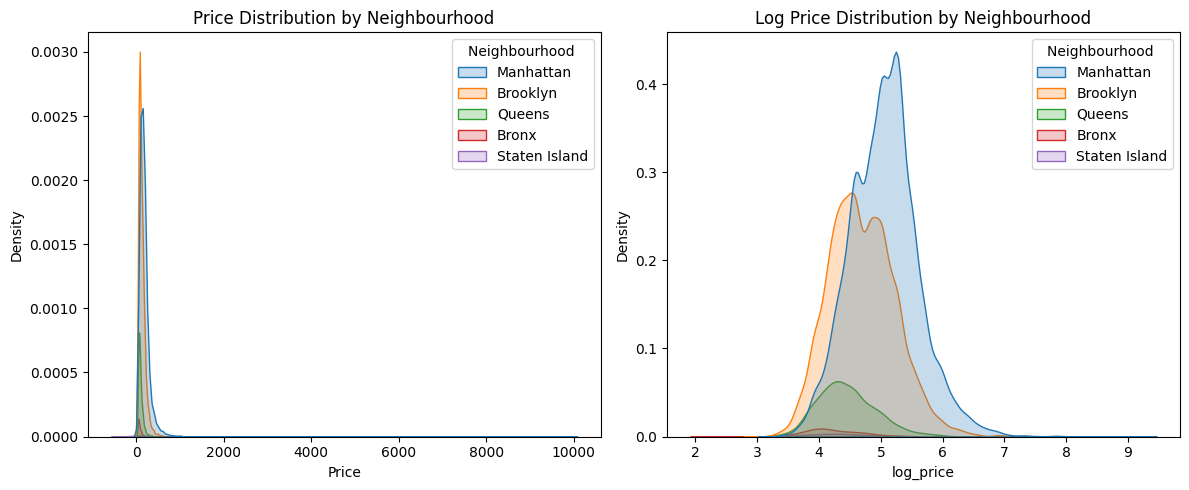

In [10]:
#Q2.1:
q1 = pd.read_csv('Q1_clean.csv')

summary = (
    q1.groupby('Neighbourhood ')[['Price', 'Review Scores Rating']]
    .mean()
    .sort_values(by='Price', ascending=False)
)
print(summary)

#most expensive borough
print("Most expensive borough:", summary.index[0])

q1['log_price'] = np.log1p(q1['Price'])

plt.figure(figsize=(12,5))
#price KDE
plt.subplot(1,2,1)
sns.kdeplot(data=q1, x='Price', hue='Neighbourhood ', fill=True)
plt.title('Price Distribution by Neighbourhood')
#log price
plt.subplot(1,2,2)
sns.kdeplot(data=q1, x='log_price', hue='Neighbourhood ', fill=True)
plt.title('Log Price Distribution by Neighbourhood')

plt.tight_layout()
plt.show()


In [11]:
#Q2.2
import statsmodels.api as sm
import pandas as pd

X = pd.get_dummies(q1['Neighbourhood '], drop_first=False)

# No intercept → do NOT add constant
y = q1['Price']

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        16:07:35   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Bronx            75.2765      9.868      7.628

In [12]:
#Q2.3:
#add intercept - same code as above buy updated
X = pd.get_dummies(q1['Neighbourhood '], drop_first=True).astype(float)

# Add intercept
X = sm.add_constant(X)

y = q1['Price']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        16:07:38   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      9.868      7.628

In [13]:
#Q2.4
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import numpy as np
import pandas as pd

#dummies
X = pd.get_dummies(q1[['Review Scores Rating', 'Neighbourhood ']], drop_first=True).astype(float)
y = q1['Price']

# Train/test split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#intercepts
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

#fit model
model = sm.OLS(y_train, X_train).fit()

#predictions
y_pred = model.predict(X_test)

#metric
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R^2:", r2)
print("RMSE:", rmse)
print(model.summary())

R^2: 0.045925883817350965
RMSE: 140.91821103729345
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     189.8
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          1.33e-197
Time:                        16:07:40   Log-Likelihood:            -1.1348e+05
No. Observations:               17722   AIC:                         2.270e+05
Df Residuals:                   17716   BIC:                         2.270e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

In [14]:
#Q2.5 , SAME AS ABOVE + Property Type included

X = pd.get_dummies(q1[['Review Scores Rating', 'Neighbourhood ', 'Property Type']], drop_first=True).astype(float)
y = q1['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

model = sm.OLS(y_train, X_train).fit()
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R^2:", r2)
print("RMSE:", rmse)
print(model.summary())

R^2: 0.054242713551245325
RMSE: 140.30266238276283
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     51.46
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          2.52e-218
Time:                        16:07:43   Log-Likelihood:            -1.1339e+05
No. Observations:               17722   AIC:                         2.268e+05
Df Residuals:                   17699   BIC:                         2.270e+05
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?

The most expensive car brands appear to be Kia, Mahindra, and Toyota, since they have the highest average and upper-end prices in the summary table. Overall, prices are fairly spread out but concentrated in the mid-to-high range, with some high-value cars pulling the distribution upward. The KDE plots show a slightly right-skewed distribution, with luxury or higher-end brands shifted further to the right compared to others.

  3. Split the data into an 80% training set and a 20% testing set.

Code below.

  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?

The numeric-only model performs very well, with a training R^2
of about 0.958 and RMSE of 0.079, and a test R^2 of about 0.953 with RMSE of 0.083. The categorical-only model performs much worse, with a test R^2 of about 0.505 and RMSE of 0.269, so the numeric model clearly performs better on the test set. The combined model slightly improves performance, with a test R^2 of about 0.958 and RMSE of 0.079, meaning it performs better than the numeric model, but only by a small margin.
  
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?

As the polynomial degree increases, training R^2
increases and RMSE decreases, while test performance improves up to degree 3 and then begins to slightly worsen, indicating the start of overfitting. In your results, R^2 never becomes negative on the test set, but it does decline at higher degrees (like degree 5). The best model is degree 3 with a test R^2 ≈0.999 and RMSE ≈ 0.013, which performs much better than the  best model from part 4.

  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

  The predicted values line up almost perfectly along the diagonal. This indicates an extremely strong fit and very accurate predictions on the test set. The residuals are tightly centered around zero and appear roughly bell-shaped. A major strength is the model’s high accuracy, but a weakness is that it may be overfitting, since such near-perfect fit is unusual and may not generalize well to new data.



In [15]:
#3.1: Load and Clean
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cars = pd.read_csv('cars_hw.csv')
# Clean column names
cars.columns = (cars.columns.str.strip().str.replace(" ", "_"))
#drop dupes
cars = cars.drop_duplicates()
#price to numeric
cars['Price'] = pd.to_numeric(cars['Price'], errors='coerce')
#drop missing key values
cars = cars.dropna(subset=['Price', 'Make'])

# Remove outliers (IQR)
Q1 = cars['Price'].quantile(0.25)
Q3 = cars['Price'].quantile(0.75)
IQR = Q3 - Q1
cars = cars[(cars['Price'] >= Q1 - 1.5*IQR) & (cars['Price'] <= Q3 + 1.5*IQR)]

#log transform
cars['log_Price'] = np.log1p(cars['Price'])

cars.head()

,Unnamed:_0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price,log_Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000,13.395441
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000,13.432786
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000,13.583580
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000,12.933624
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000,13.151924


count    922.000000
mean      13.352111
std        0.388764
min       12.144203
25%       13.048180
50%       13.380103
75%       13.637282
max       14.197366
Name: log_Price, dtype: float64
               count       mean       std        min        25%        50%  \
Make                                                                         
Chevrolet        6.0  12.919898  0.480974  12.495008  12.568395  12.752289   
Datsun           3.0  12.576050  0.036311  12.538971  12.558305  12.577640   
Ford            52.0  13.468282  0.210894  12.577640  13.361382  13.469494   
Honda           72.0  13.526472  0.328588  12.663501  13.272077  13.565091   
Hyundai        304.0  13.365216  0.395255  12.421188  13.091390  13.366095   
Jeep             1.0  14.070154       NaN  14.070154  14.070154  14.070154   
Kia              1.0  14.129592       NaN  14.129592  14.129592  14.129592   
Mahindra        18.0  13.898954  0.159906  13.587356  13.851809  13.905681   
Maruti Suzuki  293.0  13.218

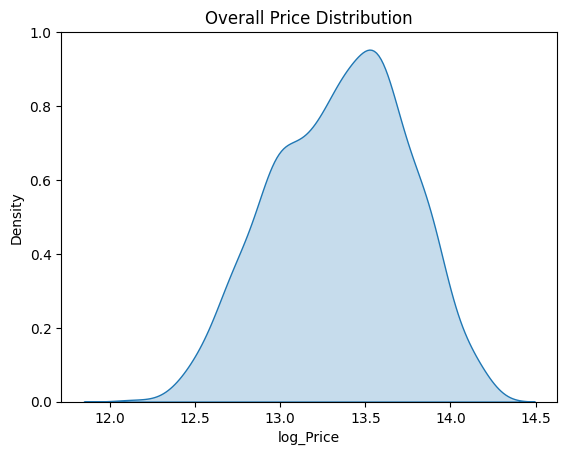

/tmp/ipykernel_14403/2394222761.py:16: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=cars, x='log_Price', hue='Make', fill=True)


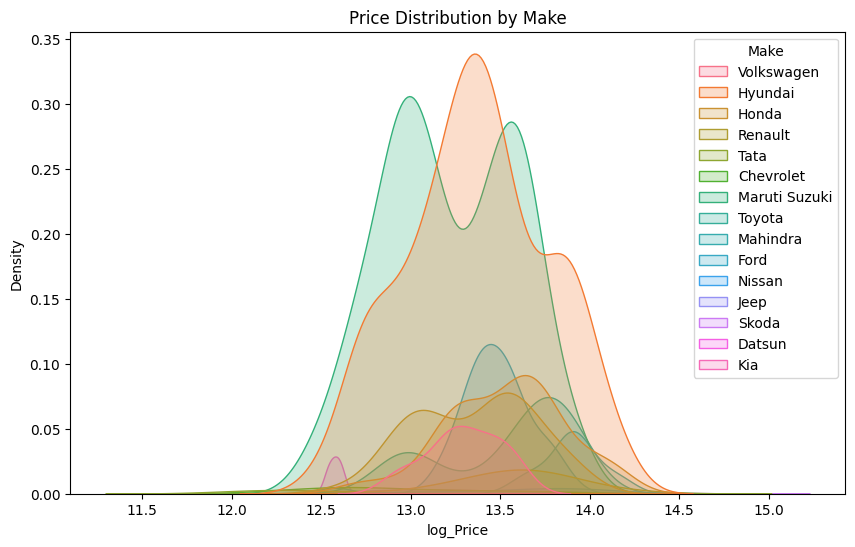

In [16]:
#Q3.2
#describe
print(cars['log_Price'].describe())

# summary
make_summary = cars.groupby('Make')['log_Price'].describe()
print(make_summary)

#overall KDE
sns.kdeplot(data=cars, x='log_Price', fill=True)
plt.title('Overall Price Distribution')
plt.show()

#KDE by make---
plt.figure(figsize=(10,6))
sns.kdeplot(data=cars, x='log_Price', hue='Make', fill=True)
plt.title('Price Distribution by Make')
plt.show()

In [17]:
#Q3.3
X = cars.drop(columns=['log_Price'])
y = cars['log_Price']
# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)


(737, 12) (185, 12)


In [21]:
#Q3.4

import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error

# --- Separate numeric and categorical ---
X_num = cars.select_dtypes(include=np.number).drop(columns=['log_Price'])
X_cat = pd.get_dummies(cars.select_dtypes(exclude=np.number), drop_first=True).astype(float)
y = cars['log_Price']

# Align with train/test split
X_train_num = X_num.loc[X_train.index]
X_test_num = X_num.loc[X_test.index]

X_train_cat = X_cat.loc[X_train.index]
X_test_cat = X_cat.loc[X_test.index]

# model 1 numeric only
X_train_n = sm.add_constant(X_train_num)
X_test_n = sm.add_constant(X_test_num)

m1 = sm.OLS(y_train, X_train_n).fit()

pred_train_1 = m1.predict(X_train_n)
pred_test_1 = m1.predict(X_test_n)

print("Model 1 (Numeric)")
print("Train R2:", r2_score(y_train, pred_train_1))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, pred_train_1)))
print("Test R2:", r2_score(y_test, pred_test_1))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, pred_test_1)))


#model 2 categorical
X_train_c = sm.add_constant(X_train_cat)
X_test_c = sm.add_constant(X_test_cat)

m2 = sm.OLS(y_train, X_train_c).fit()

pred_test_2 = m2.predict(X_test_c)

print("Model 2 (Categorical)")
print("Test R2:", r2_score(y_test, pred_test_2))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, pred_test_2)))


#model 3 combined
X_train_all = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_all = pd.concat([X_test_num, X_test_cat], axis=1)

X_train_all = sm.add_constant(X_train_all)
X_test_all = sm.add_constant(X_test_all)

m3 = sm.OLS(y_train, X_train_all).fit()

pred_test_3 = m3.predict(X_test_all)

print("Model 3 (Combined)")
print("Test R2:", r2_score(y_test, pred_test_3))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, pred_test_3)))

Model 1 (Numeric)
Train R2: 0.9584224191651716
Train RMSE: 0.07945266891128529
Test R2: 0.9526549605509623
Test RMSE: 0.08322032601608553
Model 2 (Categorical)
Test R2: 0.5054993031589081
Test RMSE: 0.26895252468346276
Model 3 (Combined)
Test R2: 0.9578392148340544
Test RMSE: 0.07853197443560807


In [22]:
#Q3.5

from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import statsmodels.api as sm

for d in range(1, 6):
    poly = PolynomialFeatures(degree=d, include_bias=False)

    X_train_poly = poly.fit_transform(X_train_num)
    X_test_poly = poly.transform(X_test_num)

    X_train_poly = sm.add_constant(X_train_poly)
    X_test_poly = sm.add_constant(X_test_poly)

    model = sm.OLS(y_train, X_train_poly).fit()

    y_pred_train = model.predict(X_train_poly)
    y_pred_test = model.predict(X_test_poly)

    print(f"\nDegree {d}")
    print("Train R2:", r2_score(y_train, y_pred_train))
    print("Test R2:", r2_score(y_test, y_pred_test))
    print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))


Degree 1
Train R2: 0.9584224191651718
Test R2: 0.9526549605509627
Test RMSE: 0.08322032601608528

Degree 2
Train R2: 0.9965579202408721
Test R2: 0.9943436931802813
Test RMSE: 0.028764620660268213

Degree 3
Train R2: 0.9995913755003832
Test R2: 0.9988836717441182
Test RMSE: 0.012778742831775028

Degree 4
Train R2: 0.9993335850168056
Test R2: 0.9988326827015771
Test RMSE: 0.013067323178369422

Degree 5
Train R2: 0.9712729106206168
Test R2: 0.932400683094969
Test RMSE: 0.09944050590793627


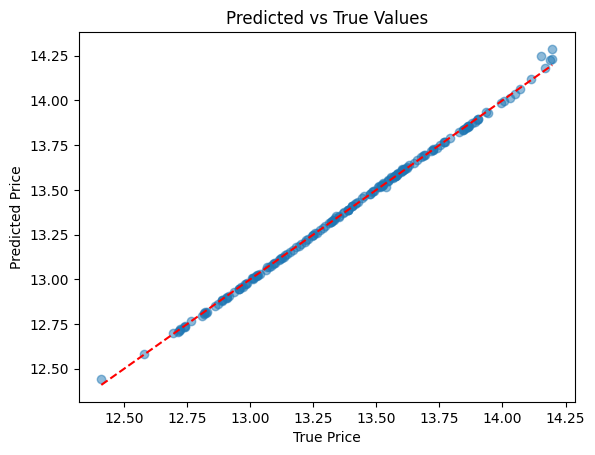

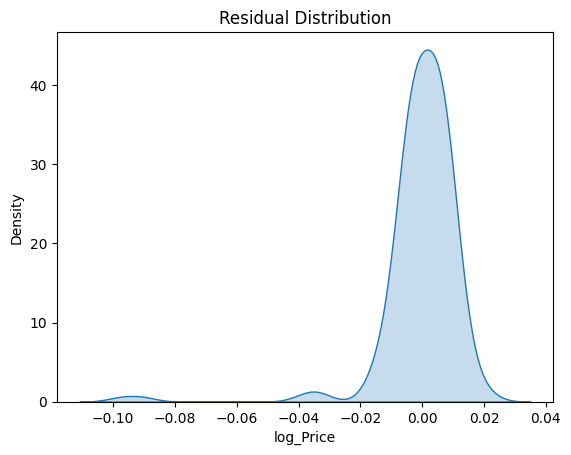

In [23]:
#Q3.6

#  best model is degree 3 from the results
poly = PolynomialFeatures(degree=3, include_bias=False)

X_train_poly = poly.fit_transform(X_train_num)
X_test_poly = poly.transform(X_test_num)

X_train_poly = sm.add_constant(X_train_poly)
X_test_poly = sm.add_constant(X_test_poly)

model = sm.OLS(y_train, X_train_poly).fit()

#predictions
y_pred = model.predict(X_test_poly)

#predictions vs true plot
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs True Values")
plt.show()

residuals = y_test - y_pred

sns.kdeplot(residuals, fill=True)
plt.title("Residual Distribution")
plt.show()

**Q4.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.

$$
SSE = \sum_{i=1}^N \left(y_i - b_0 - b_1 z_{i1} - b_2 z_{i2}\right)^2
$$

2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.

$$
\frac{\partial SSE}{\partial b_0} = -2 \sum_{i=1}^N \left(y_i - b_0 - b_1 z_{i1} - b_2 z_{i2}\right) = 0
$$

$$
\frac{\partial SSE}{\partial b_1} = -2 \sum_{i=1}^N z_{i1}\left(y_i - b_0 - b_1 z_{i1} - b_2 z_{i2}\right) = 0
$$

$$
\frac{\partial SSE}{\partial b_2} = -2 \sum_{i=1}^N z_{i2}\left(y_i - b_0 - b_1 z_{i1} - b_2 z_{i2}\right) = 0
$$

3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.

$$
\sum_{i=1}^N \left(y_i - b_0 - b_1 z_{i1} - b_2 z_{i2}\right) = 0
$$

$$
\sum_{i=1}^N e_i = 0
$$

4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.

$$
\sum_{i=1}^N y_i - N b_0 - b_1 \sum_{i=1}^N z_{i1} - b_2 \sum_{i=1}^N z_{i2} = 0
$$

$$
\sum_{i=1}^N z_{i1} = 0 \quad \text{and} \quad \sum_{i=1}^N z_{i2} = 0
$$

$$
b_0 = \frac{1}{N} \sum_{i=1}^N y_i = \bar{y}
$$

5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.

$$
\begin{bmatrix}
\sum z_{i1}^2 & \sum z_{i1} z_{i2} \\
\sum z_{i1} z_{i2} & \sum z_{i2}^2
\end{bmatrix}
\begin{bmatrix}
b_1 \\
b_2
\end{bmatrix}
=
\begin{bmatrix}
\sum z_{i1} y_i \\
\sum z_{i2} y_i
\end{bmatrix}
$$

6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.

$$
A =
\begin{bmatrix}
\frac{1}{N} \sum z_{i1}^2 & \frac{1}{N} \sum z_{i1} z_{i2} \\
\frac{1}{N} \sum z_{i1} z_{i2} & \frac{1}{N} \sum z_{i2}^2
\end{bmatrix}
=
\begin{bmatrix}
\text{Var}(z_1) & \text{Cov}(z_1, z_2) \\
\text{Cov}(z_1, z_2) & \text{Var}(z_2)
\end{bmatrix}
$$

$$
C =
\begin{bmatrix}
\frac{1}{N} \sum z_{i1} y_i \\
\frac{1}{N} \sum z_{i2} y_i
\end{bmatrix}
=
\begin{bmatrix}
\text{Cov}(z_1, y) \\
\text{Cov}(z_2, y)
\end{bmatrix}
$$

Work was done by hand but I used ChatGPT to simplify and put it into LaTex format since I am not familiar.